<p class="h1">ECE 447 - Notebook 06</p>
<p class="h1">Classification</p>
<p class="h2">Support Vector Machine (SVM) and Kernels</p>

In this section, we will cover the following concepts:
- Introduction of SVM
- Linear separable data using hard and soft merging
- Non-linear separable data and the use of kernels
- Use of SVN for regression

# Suport Vector Machine

Support vector machines (SVMs) are a class of supervised algorithms for  classification, regression and outlier detection. SVM is a discriminative classificator; instead of modeling each class, it finds a line, or curve (or manifold in multiple dimensions), that divides the classes from each other.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

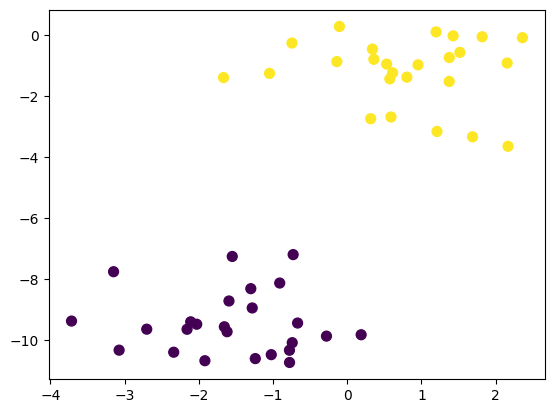

In [2]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=50, centers=2, random_state=2)
y[y==0] = -1
plt.scatter(X[:, 0], X[:, 1], c=y, s=50);

A linear discriminative classifier would attempt to draw a straight line separating the two sets of data, thereby creating a model for classification.

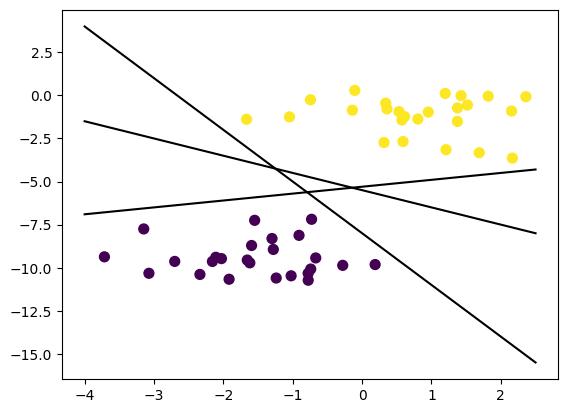

In [3]:
xfit = np.linspace(-4, 2.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50)

for m, b in [(-1, -5.5), (0.4, -5.3), (-3, -8)]:
    plt.plot(xfit, m * xfit + b, '-k')

There are multiple lines/separators that can perfectly discriminate between these samples. Depending on which we choose, a new data point will be assigned a different label. Separating classes by drawing a line between them is not enough.

Support vector machines are effective for high dimensional spaces, even in the cases where the number of dimensions is greater than the number of samples. Since it uses a subset of training points in the decision function (support vectors), it is memory efficient. However, if the number of features is much greater than the number of samples, it is necessary to use regularization to avoid over-fitting. SVMs do not provide probability estimates. To compute them, an expensive five-fold cross-validation is needed.

## Maximizing the *Margin*

Support vector machines offer one way to improve on this. Rather than simply drawing a zero-width line between the classes, we can draw a *margin* of some width around each line, up to the nearest point.

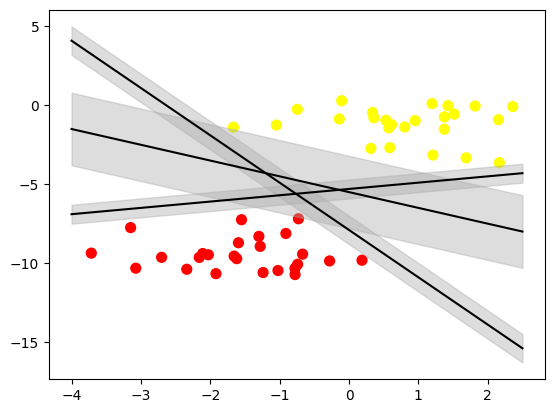

In [4]:
xfit = np.linspace(-4, 2.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')

for m, b, d in [(-1, -5.5,2.3), (0.4, -5.3, 0.6), (-3, -7.9, 0.9)]:    
    yfit = m * xfit + b
    plt.plot(xfit, yfit, '-k')
    plt.fill_between(xfit, yfit - d, yfit + d, edgecolor='none',
                     color='#AAAAAA', alpha=0.4)

In support vector machines, the line that maximizes this margin is the one we will choose as the optimal model.

# Linear separable

A binary linear classification using SVM, labels the classes $\{-1,1\}$, instead of $\{0,1\}$ used in logistic regression, and separates the parameter $\theta$ into $w$ and $b$ ($w=[\theta_1,...,\theta_n]^T$, $b=\theta_0$). With these changes, we write the hypotesis/predictor function as follows:

$$
h_{w,b}(x) = g(w^Tx+b),
$$

where

$$
g(z) =
\begin{cases}
1 & \textrm{if } z\ge 0\\
-1 & \textrm{otherwise}
\end{cases}
$$

In [8]:
def predictor(Features, Weights, b):
    z = Features @ Weights + b
    classification = np.sign(z)
    return classification

In [9]:
W = np.array([[0.388398], [0.40276394]])
b = 1.3
Yp = predictor(X,W,b).flatten()

In [10]:
def hyperplane2(x,w,b,v):
            return (-w[0]*x-b+v) / w[1]
def hyperplane(x,w,b,v):
            return (-(w[0]*x)-b) / w[1] + 2*v

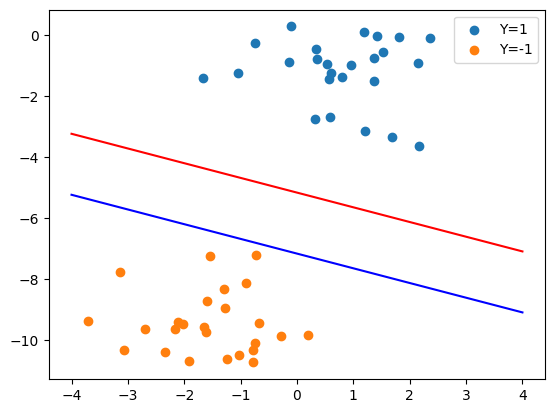

In [11]:
plt.scatter(X[:,0][Yp==1],X[:,1][Yp==1],label="Y=1")
plt.scatter(X[:,0][Yp==-1],X[:,1][Yp==-1],label="Y=-1")
plt.plot([-4, 4], [hyperplane(0,W,b,-1), hyperplane(4,W,b,-1)],color='b')
plt.plot([-4, 4], [hyperplane(0,W,b,0), hyperplane(4,W,b,0)],color='r')
plt.legend();

## Marging

As we mentioned before, to represent the optimal model, SVM chooses the line that maximizes this margin. A margin is a separation of line to the closest class points.

![](images/margin.jpg)


The distance, $\gamma$, is defined as the distance between the separation line and the points.

$$
\gamma_i = y_i(w^Tx_i+b)\quad\quad y_i \in \{-1,1\}
$$


From the previous definition, we have, if $y_i(w^Tx_i+b)>0$, the prediction is correct. A larger margin ($\gamma$) implies more confidence on the prediction.

So the problem we want to solve is find $w$, and $b$ that maximize the margin $\gamma$, but keep the correct classification.

$$
\begin{array}{rl}
\textrm{max}_{\gamma,w,b} & \gamma \\
\textrm{s.t.} & y_i(w^Tx_i+b) \ge \gamma,\quad i=1...n\\
\end{array}
$$

By implication, maximizing the margin implies minimizing $||w||$, thus:

$$
\begin{array}{rl}
\textrm{min}_{\gamma,w,b} & \frac{1}{2}||w||^2 \\
\textrm{s.t.} & y_i(w^Tx_i+b) \ge 1,\quad i=1...n\\
\end{array}
$$

To solve this, we could use the Lagrange multipliers. However, this is outside of the scope of this secction. Check https://see.stanford.edu/materials/aimlcs229/cs229-notes3.pdf for a explanation of Lagrange duality and https://xavierbourretsicotte.github.io/SVM_implementation.html for a Python implementation. 

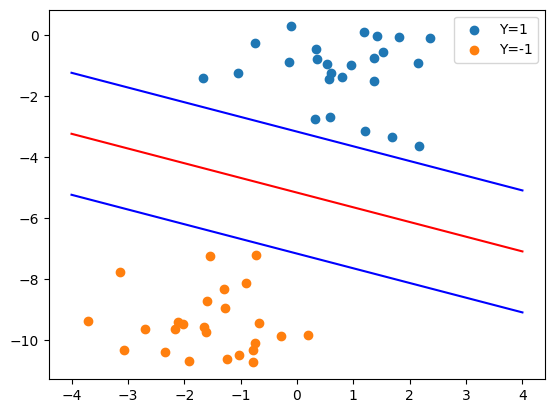

In [12]:
plt.scatter(X[:,0][Yp==1],X[:,1][Yp==1],label="Y=1")
plt.scatter(X[:,0][Yp==-1],X[:,1][Yp==-1],label="Y=-1")
plt.plot([-4, 4], [hyperplane(0,W,b,-1), hyperplane(4,W,b,-1)],color='b')
plt.plot([-4, 4], [hyperplane(0,W,b,0), hyperplane(4,W,b,0)],color='r')
plt.plot([-4, 4], [hyperplane(0,W,b,1), hyperplane(4,W,b,1)],color='b')
plt.legend();

scikit-learn provides multiple methods for support vector machines. One of those modules is `SVM`, used for classification. Since we want a linear classification, we will use the parameter `kernel='linear'`.

In [13]:
from sklearn.svm import SVC # "Support vector classifier"
model = SVC(kernel='linear')
model.fit(X, y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [14]:
model.coef_,model.intercept_

(array([[0.19648398, 0.40276394]]), array([2.03888918]))

In [15]:
def plot_svm_decision_margin(model, plot_support=True):
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)
    
    # plot decision boundary and margins
    ax.contour(X, Y, P, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    
    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:,0], model.support_vectors_[:,1],
                   s=200, linewidth=1, edgecolors='black', facecolors='none');

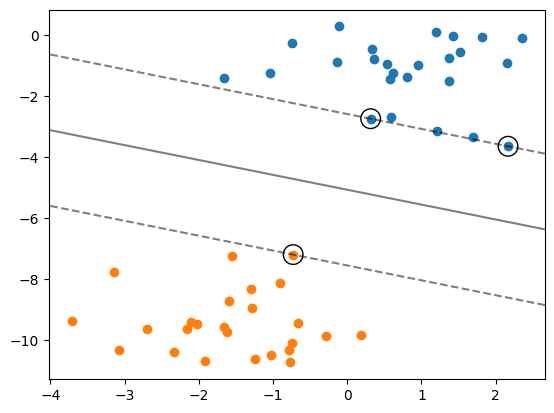

In [16]:
plt.scatter(X[:,0][Yp==1],X[:,1][Yp==1],label="Y=1")
plt.scatter(X[:,0][Yp==-1],X[:,1][Yp==-1],label="Y=-1")
plot_svm_decision_margin(model);

In the previous plot, we observe few marked points. These points are the pivotal elements of the model, and represent the support vectors of the model. These points are stored in the `support_vector_` attribute of the model.

In [17]:
model.support_vectors_

array([[-0.72864791, -7.18926735],
       [ 2.16678106, -3.63715534],
       [ 0.31557398, -2.73299117]])

In [18]:
model.coef_.T

array([[0.19648398],
       [0.40276394]])

We can check that the support vector points are the ones evaluate $y(w^Tx+b)=1$ (or close to 1)

In [19]:
w = model.coef_.T
b = model.intercept_
g = y*(X @ w +b).T
for i,sv in enumerate(g.flatten()):
    if 0.9998<=abs(sv)<=1.01:
        print(X[i],sv)

[-0.72864791 -7.18926735] 0.999856114627363
[ 1.20936556 -3.15216453] 1.0069319303371898
[ 0.31557398 -2.73299117] 1.0001441176290216


## Soft margin

The previous model is considered a model with a *hard margin classification*. It works because the data is seperable linearly and there are no outliers.
In cases where the data is not seperable linearly, we need a more flexible model. A *soft margin classification* allows violations of the hard margin, until a certain value.

![](images/soft-margin.jpg)

For example, the following set of points are not linearly separable.

Misclassification is allowed. And, the misclassification error is minimized.\
The loss of a misclassified point is called a **slack variable** and is added to the original problem. So the original problem for the soft margin becomes:

$$
\begin{array}{rl}
\textrm{min}_{\gamma,w,b} & \frac{1}{2}||w||^2 + C \sum^n_{i=1}{\xi_i}\\
\textrm{s.t.} & y_i(w^Tx_i+b) \ge 1,\quad i=1...n\\
\textrm{    } & \xi_n \geq \forall n\\
\end{array}
$$

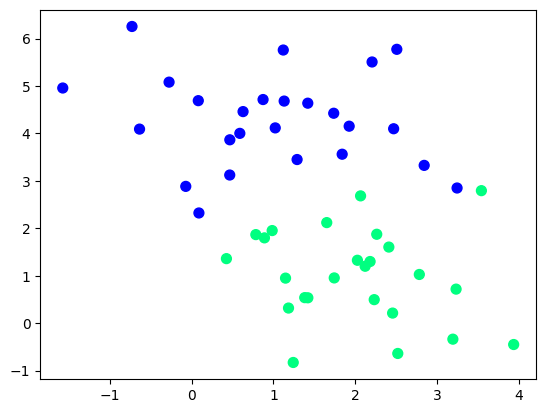

In [21]:
X, y = make_blobs(n_samples=50, centers=2, random_state=0)
y[y==0] = -1
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter');

Generating a hard margin model as follows,

In [22]:
from sklearn.svm import SVC # "Support vector classifier"
model_hard = SVC(kernel='linear', C=1e7) # C: Penalty parameter of the error term
model_hard.fit(X, y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10000000.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


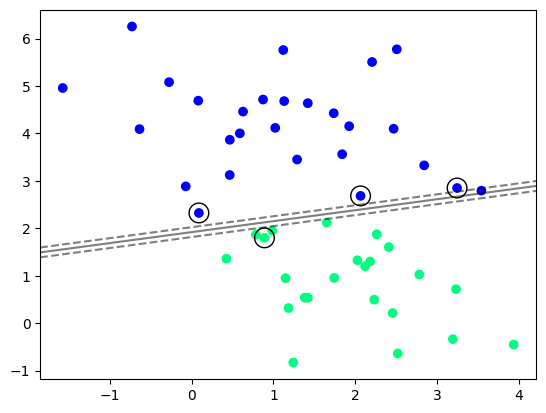

In [23]:
Yp_hard = model_hard.predict(X)
plt.scatter(X[:, 0], X[:, 1], c=Yp_hard, cmap='winter')
plot_svm_decision_margin(model_hard);

We can observe that we obtain a small margin. 

However, if we use a *soft margin* model, we have the following. (By default parameter `C=1.0`)  

In [24]:
model_soft = SVC(kernel='linear')
model_soft.fit(X, y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


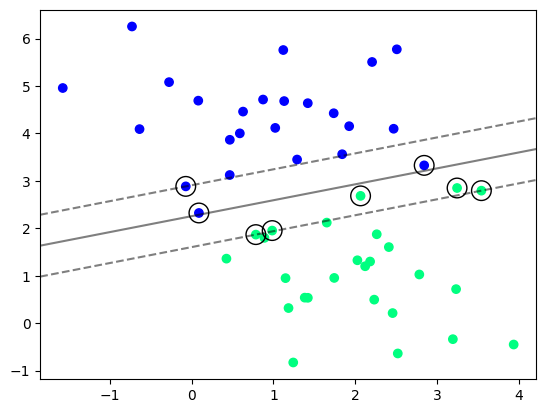

In [25]:
Yp_soft = model_soft.predict(X)
plt.scatter(X[:, 0], X[:, 1], c=Yp_soft, cmap='winter')
plot_svm_decision_margin(model_soft);

Comparing the results, we have:

In [26]:
from sklearn.metrics import accuracy_score
print("Hard Margin Model accuracity:",accuracy_score(y,Yp_hard))
print("Soft Margin Model accuracity:",accuracy_score(y,Yp_soft))

Hard Margin Model accuracity: 0.96
Soft Margin Model accuracity: 0.98


Summary:

small **C** - small penalty, we allow some misclassification  - soft margin \
large **C** - large penarly, we do not allow any misclassification - hard margin

The difference between a hard margin and a soft margin in SVMs lies in the separability of the data. 

If data is **linearly separable** - use a **hard margin**.\
If there are data points that make it impossible to find a linear classifier - data is **not linearly separable** - let some of the data points be misclassified. In this case, a **soft margin** SVM is okay to use.

## Scaling 

SVM is sensitive to scaling of features. It is recommended to perform it. It could be normalization or standardization. 

In [27]:
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [28]:
def plot_svc_decision_boundary(svm_clf, xmin, xmax):
    w = svm_clf.coef_[0]
    b = svm_clf.intercept_[0]

    # At the decision boundary, w0*x0 + w1*x1 + b = 0
    # => x1 = -w0/w1 * x0 - b/w1
    x0 = np.linspace(xmin, xmax, 200)
    decision_boundary = -w[0]/w[1] * x0 - b/w[1]

    margin = 1/w[1]
    gutter_up = decision_boundary + margin
    gutter_down = decision_boundary - margin

    svs = svm_clf.support_vectors_
    plt.scatter(svs[:, 0], svs[:, 1], s=180, facecolors='#FFAAAA')
    plt.plot(x0, decision_boundary, "k-", linewidth=2)
    plt.plot(x0, gutter_up, "k--", linewidth=2)
    plt.plot(x0, gutter_down, "k--", linewidth=2)

Simple example showing an application of sklern functions StandardScaler and Pipeline.

(np.float64(-2.0), np.float64(2.0), np.float64(-2.0), np.float64(2.0))

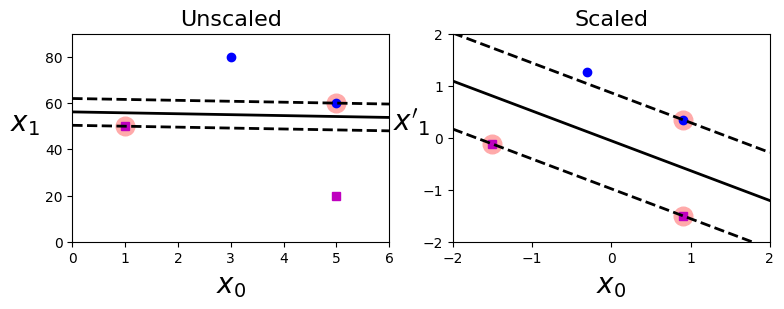

In [29]:
Xs = np.array([[1, 50], [5, 20], [3, 80], [5, 60]]).astype(np.float64)
ys = np.array([0, 0, 1, 1])
svm_clf = SVC(kernel="linear", C=100)
svm_clf.fit(Xs, ys)

plt.figure(figsize=(9,2.7))
plt.subplot(121)
plt.plot(Xs[:, 0][ys==1], Xs[:, 1][ys==1], "bo")
plt.plot(Xs[:, 0][ys==0], Xs[:, 1][ys==0], "ms")
plot_svc_decision_boundary(svm_clf, 0, 6)
plt.xlabel("$x_0$", fontsize=20)
plt.ylabel("$x_1$    ", fontsize=20, rotation=0)
plt.title("Unscaled", fontsize=16)
plt.axis([0, 6, 0, 90])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(Xs)
svm_clf.fit(X_scaled, ys)

plt.subplot(122)
plt.plot(X_scaled[:, 0][ys==1], X_scaled[:, 1][ys==1], "bo")
plt.plot(X_scaled[:, 0][ys==0], X_scaled[:, 1][ys==0], "ms")
plot_svc_decision_boundary(svm_clf, -2, 2)
plt.xlabel("$x_0$", fontsize=20)
plt.ylabel("$x'_1$  ", fontsize=20, rotation=0)
plt.title("Scaled", fontsize=16)
plt.axis([-2, 2, -2, 2])


In [30]:
est = make_pipeline(StandardScaler(), SGDClassifier())

In [31]:
est.fit(X,y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('sgdclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multip

In [32]:
est.predict([[1.0,5.0]])

array([-1])

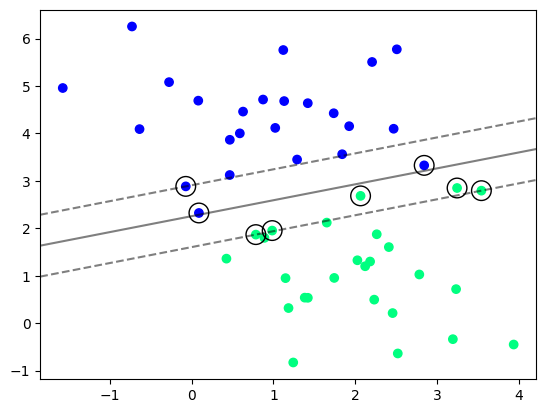

In [33]:
Yp_est = est.predict(X)
plt.scatter(X[:, 0], X[:, 1], c=Yp_est, cmap='winter')
plot_svm_decision_margin(model_soft);

In [34]:
from sklearn.metrics import accuracy_score
print("Hard Margin Model accuracity:",accuracy_score(y,Yp_hard))
print("Soft Margin Model accuracity:",accuracy_score(y,Yp_soft))
print("Scaled Margin Model accuracity:",accuracy_score(y,Yp_soft))

Hard Margin Model accuracity: 0.96
Soft Margin Model accuracity: 0.98
Scaled Margin Model accuracity: 0.98


**To review**

- For larger values of C, a smaller margin will be accepted if the decision function is better at classifying all training points correctly.
- A lower C will encourage a larger margin, therefore a simpler decision function, at the cost of training accuracy.
- In other words, C behaves as a regularization parameter in the SVM.

<div class="alert alert-success">
<h2>Exercise</h2>

✏️ Using the dataset generated for the following code, train an SVM model considering both hard margin and soft margin models. Compare the accuracy of the models.

    from sklearn.datasets.samples_generator import make_gaussian_quantiles
    X, y = make_gaussian_quantiles(n_samples=100, n_features=2, n_classes=2, random_state=2)

</div>



# Non linear separability

Using SVM with soft margin classification helps to improve the accuracy of our model. However, the presented example is still considered linear separable. 

Let's now try a more complex, non linearly separable dataset:

In [35]:
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.3, noise=.1)

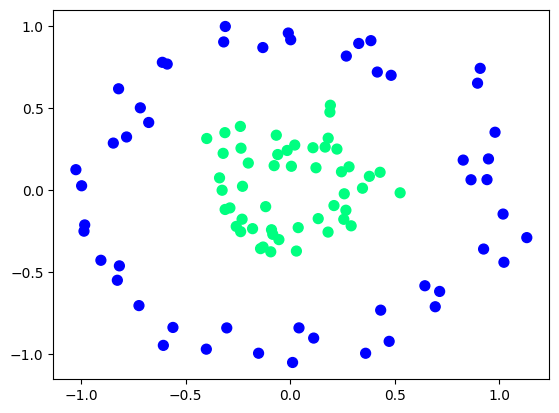

In [36]:
y[y==0] = -1
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter');

In [37]:
model = SVC(kernel='linear', C=1e4)
model.fit(X, y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10000.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


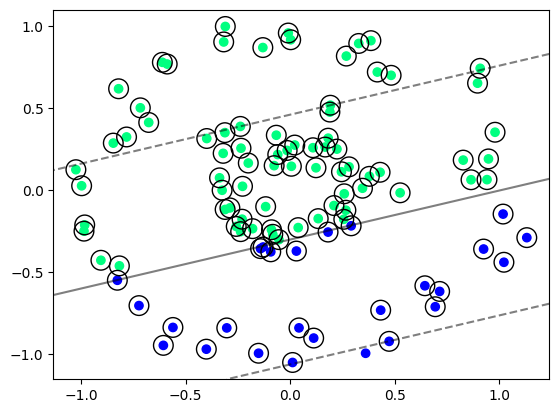

In [38]:
Yp = model.predict(X)
plt.scatter(X[:, 0], X[:, 1], c=Yp, cmap='winter')
plot_svm_decision_margin(model);

It is clear that using a linear kernel will not provides a good model of classification.

Let's change the kernel to use a polynomial kernel (`kernel='poly'`)

In [39]:
model = SVC(kernel='poly', degree=2, gamma='auto', C=1e2)
model.fit(X, y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",2
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'auto'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


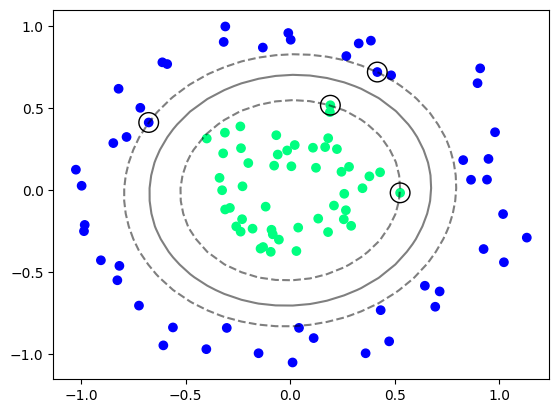

In [40]:
Yp = model.predict(X)
plt.scatter(X[:, 0], X[:, 1], c=Yp, cmap='winter')
plot_svm_decision_margin(model);

In this case, a polynomial of degree 2 is enough to obtain a model that can classify both classes.

# Kernels

The polynomial kernel used in the previous example is a way to increase the dimensionality of our problem. Increasing the dimension over the features space, helps to find the hyperplanes for classification. There are different types of kernels. For example, a *radial basis function* will help us to separate the centre points from the outer points.

In [41]:
r = np.exp(-(X ** 2).sum(1))

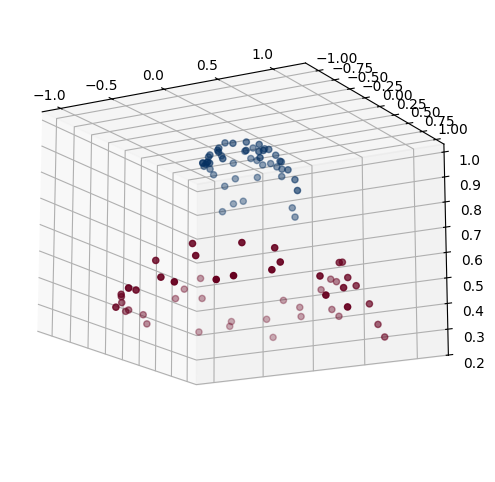

In [42]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=-15, azim=-60)
ax.scatter(X[:,0], X[:,1], r, c=y, cmap='RdBu');

We observe that with this additional dimension, the data easily becomes linearly separable, by a separating plane.

In [43]:
model = SVC(kernel='rbf', gamma='auto', C=1e2)
model.fit(X, y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'auto'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


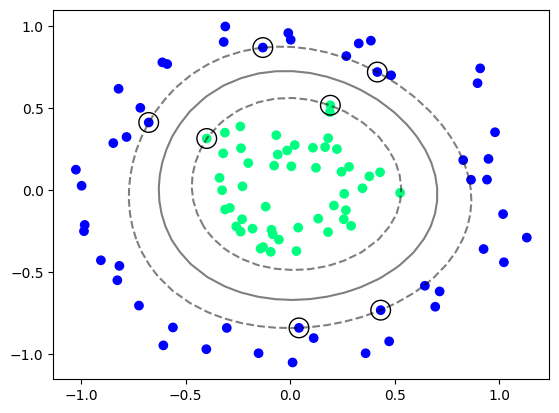

In [44]:
Yp = model.predict(X)
plt.scatter(X[:, 0], X[:, 1], c=Yp, cmap='winter')
plot_svm_decision_margin(model);

Using a kernelized support vector machine, the model earns a suitable nonlinear decision boundary. A kernel transformation strategy can be used to turn fast linear machine learning methods into fast nonlinear methods, especially for models in which the kernel trick can be used.

## RBF Kernel 

We have already shown the effect of the *radial basis function*. A more formal specification, the RBF kernel on two samples x and x', represented as feature vectors in some input space, is defined as

$$
K(x,x')=\exp \left(-{\frac{\|x -x' \|^2}{2\sigma^2}}\right) = \exp(-\gamma(\|x -x' \|^2), 
$$

where $x$ and $x'$ are two samples represented as feature vectors in some input space, and $\|x-x'\|^2$ is the squared Euclidean distance between the two feature vectors,
$\gamma=\frac{1}{2\sigma^2}$

## Polynomial Kernel

The previous used polynomial kernel is defined as:

$$
K(x,x')=(x^Tx'+c)^d
$$

where $x$ and $x'$ are vectors in the input space, and $c\ge 0$ is a free parameter to variate the influence of higher-order versus lower-order terms in the polynomial.

In [45]:
r = ((X**2+1).sum(1))**2  # c=1, d=2

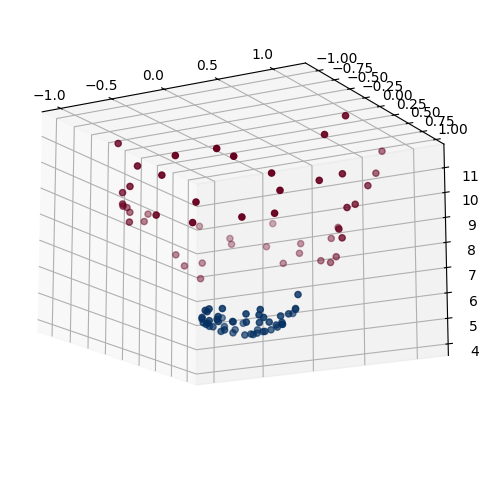

In [46]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=-15, azim=-60)
ax.scatter(X[:,0], X[:,1], r, c=y, cmap='RdBu');

# Hyperparameters

It is important to tune to two model parameters (hyperparameters).

- **C**: The C parameter helps to decides the margin width of the SVM classifier. A large value of C makes the classifier more strict about points passed the margin (hard margin), resulting in a small margin width. A very small value of C will relax the constraint, allowing points over the margin (soft margin), resulting in larger margin-separating hyperplane, even if that hyperplane misclassifies more points.

- **Gamma ($\gamma$)**
The gamma parameter defines how far the influence of a single training point is considered. With low gamma, points far away from a plausible seperation line are considered in calculating the seperation line. Whereas high gamma means the points close to the plausible line are considered in the calculation, the gamma parameter is invalid for a linear kernel in scikit-learn.

<div class="alert alert-success">
<h2>Exercise</h2>

✏️ Using the dataset generated for the following code, train an SVM model considering different kernels. Compare the accuracy of the models.


    from sklearn.datasets.samples_generator import make_gaussian_quantiles
    X, y = make_gaussian_quantiles(n_samples=100, n_features=2, n_classes=2, random_state=8)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter')

</div>



# SVM for regression

As mentioned before, SVM can be used for regression. Scikit-learn provides the module `SVR` to perform regression. The same kernels can be applied during regression.

Let's consider the following example.

In [47]:
X = np.sort(5 * np.random.rand(40, 1), axis=0)
y = np.cos(X+1.5).ravel()+np.random.ranf(40)/4

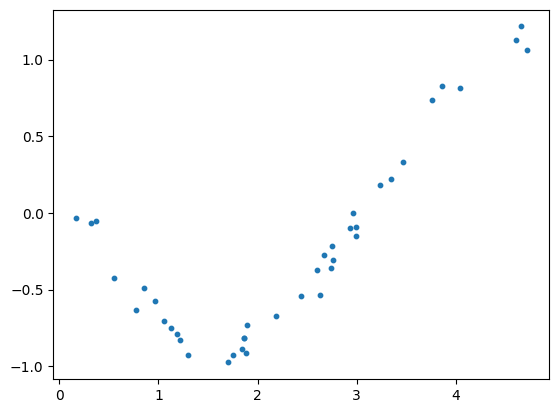

In [48]:
plt.scatter(X,y,s=10);

In [49]:
from sklearn.svm import SVR

In [50]:
svrs = [SVR(kernel='linear', gamma='auto'),
        SVR(kernel='poly', gamma='auto'),
        SVR(kernel='rbf', gamma='auto')]

In [51]:
for model in svrs:
    model.fit(X,y)

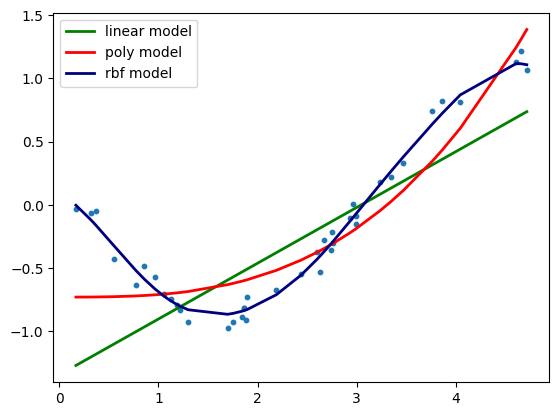

In [52]:
lw = 2
plt.scatter(X, y,s=10)
plt.plot(X, svrs[0].predict(X), color='green', lw=lw, label='linear model')
plt.plot(X, svrs[1].predict(X), color='red', lw=lw, label='poly model')
plt.plot(X, svrs[2].predict(X), color='navy', lw=lw, label='rbf model')
plt.legend();

We can observe that, compared with the other kernels, *rbf* produces a good data regression.

<div class="alert alert-success">
<h2>Exercise</h2>

✏️ Using the dataset generated for the following code, generate a SVR model considering different kernels, and compare the accuracy of each model.

    np.random.seed(1)
    X = np.sort(5 * np.random.rand(40, 1), axis=0)
    y = np.cos(X-0.7).ravel()-np.sin(0.7*X+0.5).ravel()+np.random.ranf(40)/3
    plt.scatter(X,y,s=10);

</div>



# Recap

In this section we introduced Support Vector Machine (SVM) as a technique for classification and regression. The idea behind SVM is to find the larger margin that separates classes. We can have both hard and soft margin. For non-linear separable data, SVM uses kernels to increase the feature dimension. This helps us find a hyperplane to separate the data. We presented linear, polynomial and radial basis function (rbf) kernels. The behaviour of SVM is modified by two parameters *C* and *gamma*. Finally, we show how SVM can be used to do data regression.